# Language Analyzer - Master Literature Analysis

This notebook demonstrates the usage of the `language_analyzer` library to analyze a comprehensive language dictionary and multiple works of classic literature. We will extract lexical statistics, calculate word frequencies, and evaluate the stylistic similarity between texts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from language_analyzer import (
    analyze_dictionary,
    build_works_dataframe,
    compute_similarity,
    df_top_n,
    preprocess_and_tokenize,
)

In [2]:
# Resolve paths relative to the notebook location
PROJECT_ROOT = Path(".").resolve().parent
dictionary_path = str(PROJECT_ROOT / "data" / "dictionaries" / "polski.txt")
works_paths = [
    str(PROJECT_ROOT / "data" / "works" / "Mickiewicz" / "Pan Tadeusz.txt"),
    str(PROJECT_ROOT / "data" / "works" / "Mickiewicz" / "Konrad Wallenrod.txt"),
    str(PROJECT_ROOT / "data" / "works" / "Sienkiewicz" / "Quo vadis.txt"),
    str(PROJECT_ROOT / "data" / "works" / "Sienkiewicz" / "Pan Wołodyjowski.txt"),
]
replacements = ["é:e"]

## 1. Dictionary Analysis

In [3]:
dict_stats, form_to_base = analyze_dictionary(dictionary_path)

In [4]:
print(f"Dictionary Lines: {dict_stats['lines_count']}")
print(f"Dictionary Words: {dict_stats['words_count']}")
print(f"Dictionary Unique Words: {dict_stats['unique_words_count']}")

Dictionary Lines: 236006
Dictionary Words: 4521735
Dictionary Unique Words: 226280


As expected for the Polish language, the most frequently occurring letters are vowels - specifically *'i'*, *'a'*, *'o'*, and *'e'*. The consonant *'n'* also features prominently. Each of these five letters appears over 4 million times in the dictionary, while all other letters appear significantly less frequently (under 3 million times).

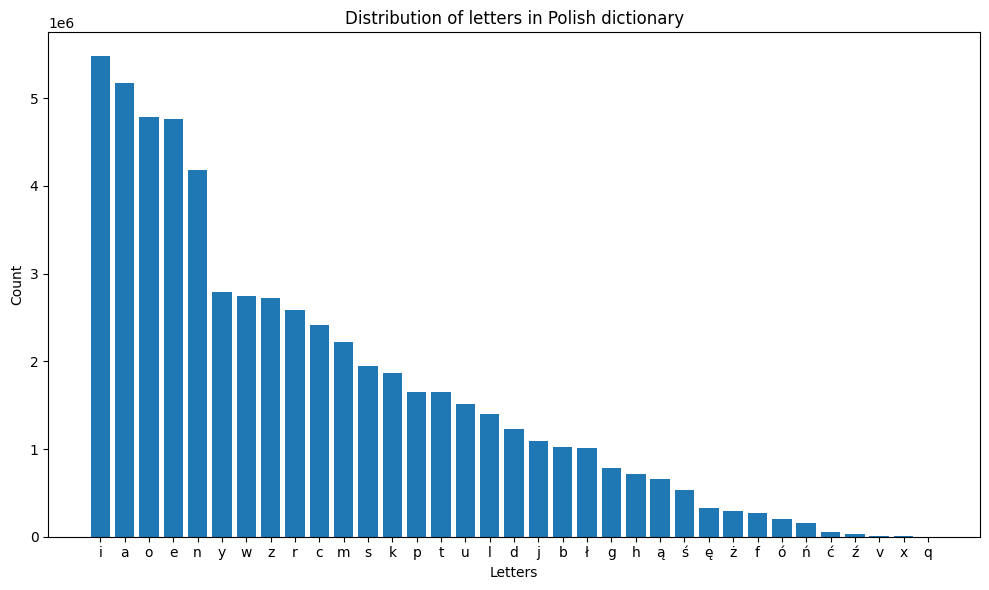

In [5]:
letters, counts = list(zip(*dict_stats["letters_count"], strict=True))

plt.figure(figsize=(10, 6))
plt.bar(letters, counts)
plt.title("Distribution of letters in Polish dictionary")
plt.xlabel("Letters")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2. Literature Analysis

### Top Words

In [6]:
works_data = {}
works_stats_dict = {}
for work in works_paths:
    words, stats = preprocess_and_tokenize(work, replacements, form_to_base)
    works_data[work] = words
    works_stats_dict[work] = stats

# Build the Pandas DataFrame of words in masters's works
df = build_works_dataframe(works_data, form_to_base)
df.head(10)

,/Users/michalmarczak/Developer/projects/NPD_Final_Assignment/data/works/Mickiewicz/Pan Tadeusz.txt,/Users/michalmarczak/Developer/projects/NPD_Final_Assignment/data/works/Mickiewicz/Konrad Wallenrod.txt,/Users/michalmarczak/Developer/projects/NPD_Final_Assignment/data/works/Sienkiewicz/Quo vadis.txt,/Users/michalmarczak/Developer/projects/NPD_Final_Assignment/data/works/Sienkiewicz/Pan Wołodyjowski.txt,total_count,in_dictionary
adam,4,1,0,13,18,True
mickiewicz,8,1,0,0,9,True
pan,359,5,377,1608,2349,True
tadeusz,174,0,0,0,174,True
czyli,21,3,5,21,50,True
ostatni,47,11,60,69,187,True
zajazd,16,0,0,1,17,True
na,1305,211,2913,2917,7346,True
litwa,58,49,0,7,114,True
księga,20,3,2,1,26,True


Analyzing the 10 most frequently occurring words across the combined works reveals that they are predominantly short prepositions or conjunctions (e.g., *'i'*, *'w'*). This is typical for natural languages.

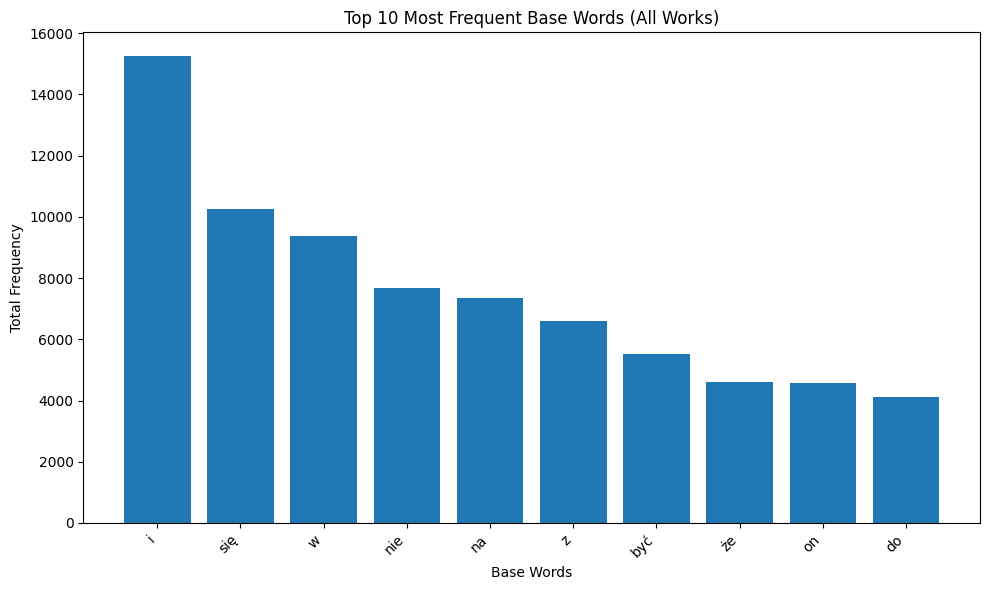

In [7]:
# Plotting the top 10 words total
top_10 = df_top_n(df, "total_count", 10)
words = [x[0] for x in top_10]
counts = [x[1] for x in top_10]

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Base Words (All Works)")
plt.xlabel("Base Words")
plt.ylabel("Total Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Stylistic Similarity Calculation

To quantify the stylistic similarity between any two works, we utilize the **Jaccard Similarity Index**.

#### How the Jaccard Index works:
The Jaccard index compares two sets to see how much they overlap. For two literary works, we first extract the set of their $N$ most frequent base words. Let $A$ be the set of top words from Work 1, and $B$ be the set of top words from Work 2.

The similarity score is calculated as the size of the intersection divided by the size of the union of the two sets, multiplied by 100 to yield a percentage:

$$ J(A, B) = \frac{|A \cap B|}{|A \cup B|} \times 100 $$

A score of 100 indicates identical top vocabularies, while a score of 0 indicates completely disjoint sets of top words.

Using the `compute_similarity` function, we calculate this metric for each pair of texts based on their most frequent words. The bigger then $N$, the lower the score tends to be for two works. The index seems to seperate the works better by theme and structure than by author.

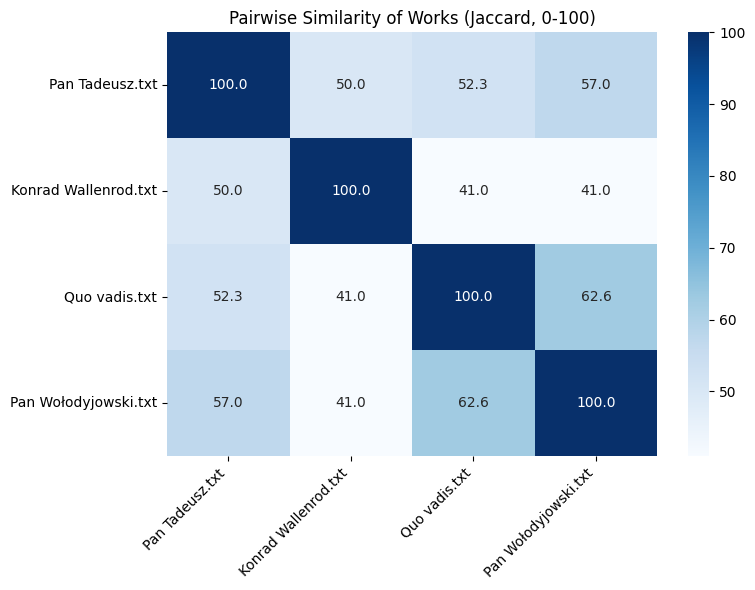

In [8]:
n = len(works_paths)
sim_matrix = np.zeros((n, n))
names = [Path(w).name for w in works_paths]

for i in range(n):
    for j in range(n):
        if i == j:
            sim_matrix[i, j] = 100.0
        else:
            sim_matrix[i, j] = compute_similarity(
                df, works_paths[i], works_paths[j], 100
            )

plt.figure(figsize=(8, 6))
sns.heatmap(
    sim_matrix,
    annot=True,
    xticklabels=names,
    yticklabels=names,
    cmap="Blues",
    fmt=".1f",
)
plt.title("Pairwise Similarity of Works (Jaccard, 0-100)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

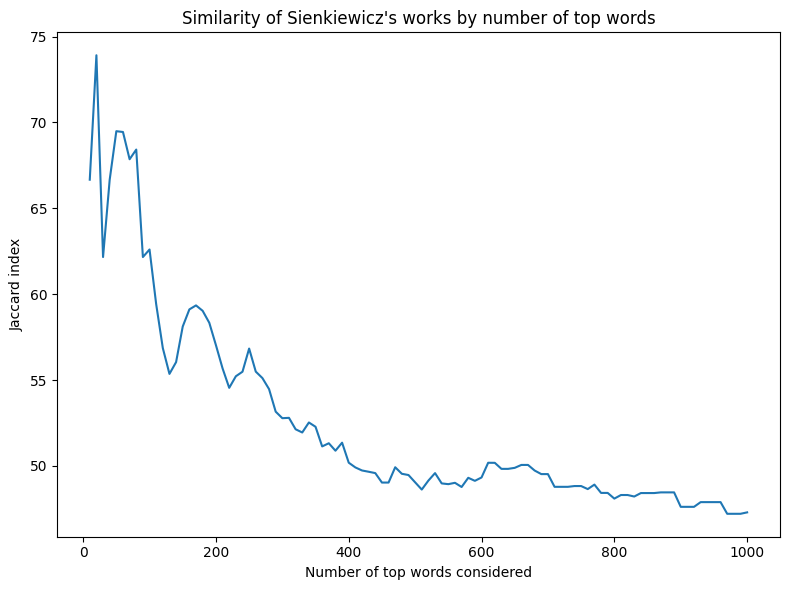

In [9]:
freq = [int(10 * x) for x in range(1, 101)]
sim_vec = np.zeros(len(freq))

for i, f in enumerate(freq):
    sim_vec[i] = compute_similarity(df, works_paths[2], works_paths[3], f)

plt.figure(figsize=(8, 6))
plt.plot(freq, sim_vec)
plt.title("Similarity of Sienkiewicz's works by number of top words")
plt.xlabel("Number of top words considered")
plt.ylabel("Jaccard index")
plt.tight_layout()
plt.show()

### Lexical Richness (Proportion of Unique Words)

Lexical richness can be approximated by observing the ratio of unique base words to the total number of words. The bar chart below illustrates this vocabulary diversity for each work. Shorter works written in verse tend to be richer in vocabulary.

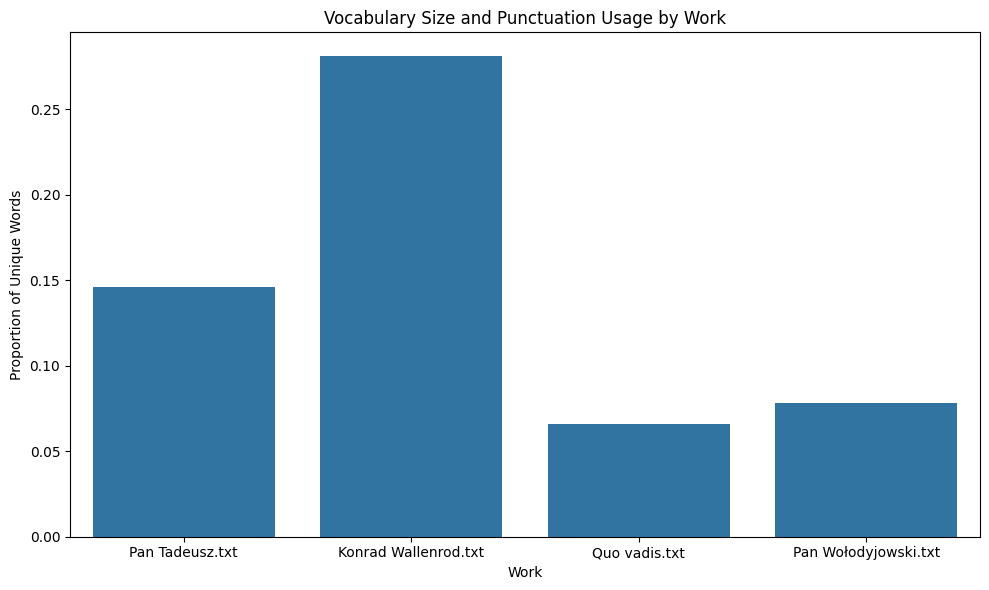

In [10]:
proportion_unique = [
    works_stats_dict[w]["unique_words_count"] / works_stats_dict[w]["words_count"]
    for w in works_paths
]

bar_df = pd.DataFrame(
    {
        "Work": [Path(w).name for w in works_paths],
        "Proportion": proportion_unique,
    }
)

plt.figure(figsize=(10, 6))
sns.barplot(data=bar_df, x="Work", y="Proportion")
plt.title("Vocabulary Size and Punctuation Usage by Work")
plt.ylabel("Proportion of Unique Words")
plt.tight_layout()
plt.show()

### Word Length Distribution

The violin plot below displays the density of word lengths across the texts, providing insight into the authors' preferences for longer, more complex words versus shorter ones. Longer, more complex works tend to use longer words.

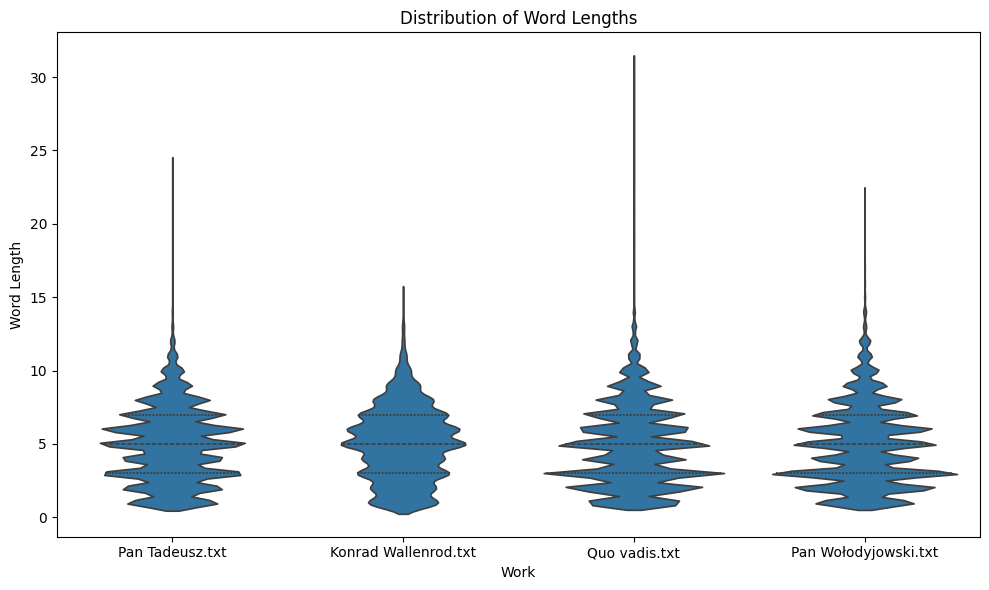

In [11]:
length_data = []
for work in works_paths:
    name = Path(work).name
    lengths = [len(w) for w in works_data[work]]
    length_data.extend([{"Work": name, "Word Length": ln} for ln in lengths])

len_df = pd.DataFrame(length_data)

plt.figure(figsize=(10, 6))
sns.violinplot(data=len_df, x="Work", y="Word Length", inner="quartile")
plt.title("Distribution of Word Lengths")
plt.tight_layout()
plt.show()